In [10]:
print("""
============================================================
FINAL EXPERIMENTAL CONCLUSION
============================================================

The experimental results demonstrate that pretrained
Transformer models outperform the traditional TF-IDF-based
machine-learning baselines on the IMDb sentiment
classification task.

Among the evaluated models, RoBERTa achieved the strongest
overall performance with an F1-score of 93.30% and an
accuracy of 93.23%.

BERT achieved an F1-score of 91.83%, while Logistic Regression
and Linear SVM achieved F1-scores of 89.71% and 89.60%,
respectively.

RoBERTa improved F1 by approximately 3.70 percentage points
over the Linear SVM baseline and 1.47 percentage points over
BERT.

These results suggest that contextual representations learned
through Transformer pretraining provide a measurable advantage
for sentiment classification compared with sparse TF-IDF
representations.
""")


FINAL EXPERIMENTAL CONCLUSION

The experimental results demonstrate that pretrained
Transformer models outperform the traditional TF-IDF-based
machine-learning baselines on the IMDb sentiment
classification task.

Among the evaluated models, RoBERTa achieved the strongest
overall performance with an F1-score of 93.30% and an
accuracy of 93.23%.

BERT achieved an F1-score of 91.83%, while Logistic Regression
and Linear SVM achieved F1-scores of 89.71% and 89.60%,
respectively.

RoBERTa improved F1 by approximately 3.70 percentage points
over the Linear SVM baseline and 1.47 percentage points over
BERT.

These results suggest that contextual representations learned
through Transformer pretraining provide a measurable advantage
for sentiment classification compared with sparse TF-IDF
representations.



In [9]:
traditional_models = final_results[
    final_results["Model"].isin([
        "Logistic Regression",
        "Linear SVM"
    ])
]

transformer_models = final_results[
    final_results["Model"].isin([
        "BERT",
        "RoBERTa"
    ])
]

traditional_f1 = traditional_models["F1"].mean()
transformer_f1 = transformer_models["F1"].mean()

print("=" * 60)
print("TRADITIONAL ML vs TRANSFORMERS")
print("=" * 60)

print(
    f"Traditional ML average F1 : "
    f"{traditional_f1:.4f}"
)

print(
    f"Transformer average F1    : "
    f"{transformer_f1:.4f}"
)

print(
    f"Improvement               : "
    f"{(transformer_f1 - traditional_f1) * 100:.2f} "
    f"percentage points"
)

TRADITIONAL ML vs TRANSFORMERS
Traditional ML average F1 : 0.8965
Transformer average F1    : 0.9257
Improvement               : 2.91 percentage points


In [8]:
svm_f1 = final_results.loc[
    final_results["Model"] == "Linear SVM",
    "F1"
].iloc[0]

bert_f1 = final_results.loc[
    final_results["Model"] == "BERT",
    "F1"
].iloc[0]

roberta_f1 = final_results.loc[
    final_results["Model"] == "RoBERTa",
    "F1"
].iloc[0]

print("F1 improvement over Linear SVM")
print("=" * 50)

print(
    f"BERT: "
    f"{(bert_f1 - svm_f1) * 100:.2f} percentage points"
)

print(
    f"RoBERTa: "
    f"{(roberta_f1 - svm_f1) * 100:.2f} percentage points"
)

print(
    f"RoBERTa over BERT: "
    f"{(roberta_f1 - bert_f1) * 100:.2f} percentage points"
)

F1 improvement over Linear SVM
BERT: 2.23 percentage points
RoBERTa: 3.70 percentage points
RoBERTa over BERT: 1.47 percentage points


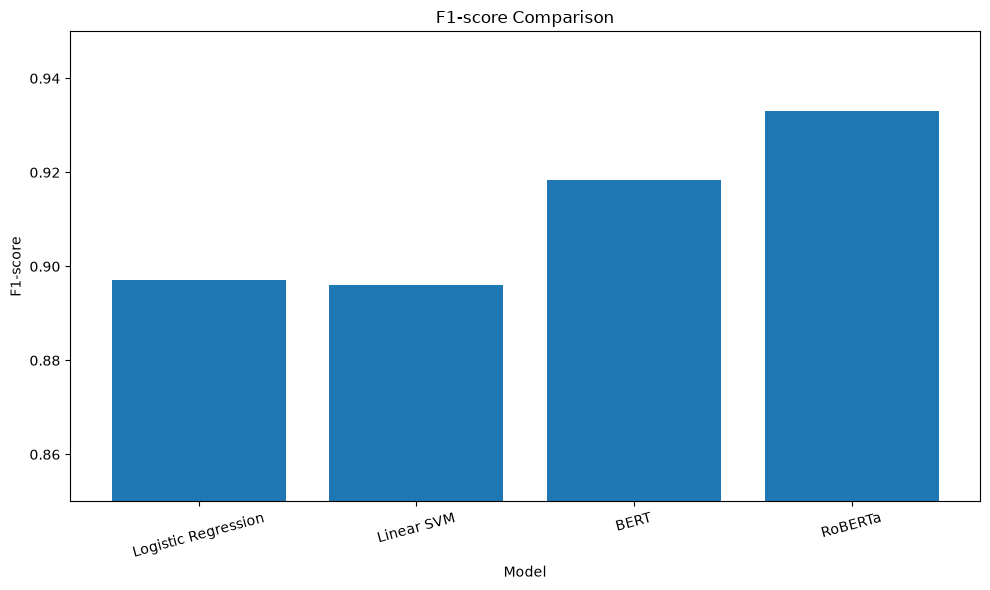

Saved: D:\Mitacs\transformer-text-classification\results\figures\f1_comparison.png


In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["F1"]
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title("F1-score Comparison")

plt.ylim(0.85, 0.95)

plt.xticks(rotation=15)

plt.tight_layout()

f1_path = FIGURES_DIR / "f1_comparison.png"

plt.savefig(
    f1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {f1_path.resolve()}")

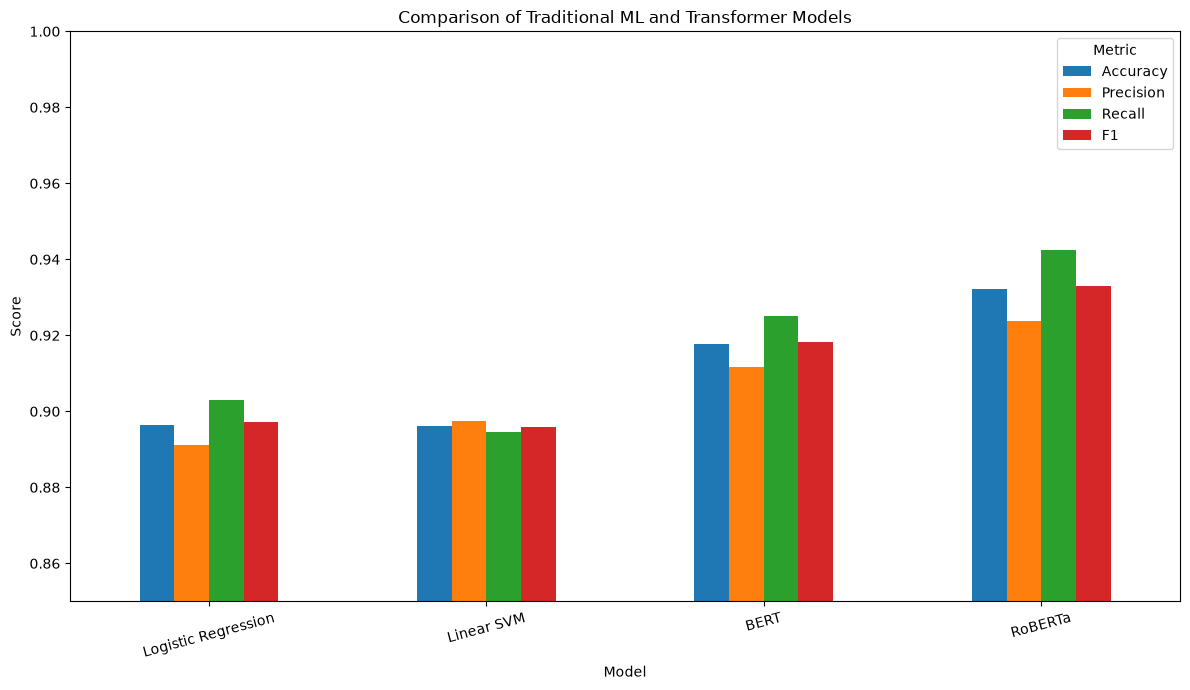

Saved: D:\Mitacs\transformer-text-classification\results\figures\model_performance_comparison.png


In [6]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

plot_df = final_results.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title(
    "Comparison of Traditional ML and Transformer Models"
)

ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0.85, 1.00)

plt.xticks(rotation=15)
plt.legend(title="Metric")

plt.tight_layout()

comparison_path = (
    FIGURES_DIR / "model_performance_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {comparison_path.resolve()}")

In [5]:
best_model = ranking.iloc[0]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.2%}")
print(f"Precision : {best_model['Precision']:.2%}")
print(f"Recall    : {best_model['Recall']:.2%}")
print(f"F1-score  : {best_model['F1']:.2%}")

BEST MODEL
Model     : RoBERTa
Accuracy  : 93.23%
Precision : 92.38%
Recall    : 94.24%
F1-score  : 93.30%


In [4]:
ranking = final_results.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

ranking.insert(
    0,
    "Rank",
    range(1, len(ranking) + 1)
)

ranking

,Rank,Model,Accuracy,Precision,Recall,F1
0,1,RoBERTa,0.9323,0.9238,0.9424,0.9330
1,2,BERT,0.9177,0.9116,0.9252,0.9183
2,3,Logistic Regression,0.8964,0.8912,0.9030,0.8971
3,4,Linear SVM,0.8962,0.8974,0.8947,0.8960


In [3]:
metrics_path = RESULTS_DIR / "final_metrics.csv"

final_results.to_csv(
    metrics_path,
    index=False
)

print(f"Saved: {metrics_path.resolve()}")

Saved: D:\Mitacs\transformer-text-classification\results\final_metrics.csv


In [2]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "BERT",
        "RoBERTa"
    ],
    "Accuracy": [
        0.8964,
        0.8962,
        0.9177,
        0.9323
    ],
    "Precision": [
        0.8912,
        0.8974,
        0.9116,
        0.9238
    ],
    "Recall": [
        0.9030,
        0.8947,
        0.9252,
        0.9424
    ],
    "F1": [
        0.8971,
        0.8960,
        0.9183,
        0.9330
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8964,0.8912,0.9030,0.8971
1,Linear SVM,0.8962,0.8974,0.8947,0.8960
2,BERT,0.9177,0.9116,0.9252,0.9183
3,RoBERTa,0.9323,0.9238,0.9424,0.9330


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Model comparison environment ready.")

Model comparison environment ready.
